In [1]:
# update pip if you need

# !pip install -U pip
# !pip --version

In [2]:
# install pymdp jax branch

# !pip install git+https://github.com/infer-actively/pymdp.git@v1.0.0_alpha

In [3]:
# Do not this on Google Colab

# update jax library in your environment

# !pip install --upgrade "jax[cuda13]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html --trusted-host storage.googleapis.com

In [4]:
# install jax for TPU on Google Colab

#!pip install jax[tpu] -f https://storage.googleapis.com/jax-releases/libtpu_releases.html

In [5]:
#!pip install jax-smi

In [6]:
# !pip install wheel setuptools pip --upgrade

In [7]:
# !pip install swig

In [8]:
# install gymnaaium classic control

# !pip install gymnasium[classic-control]

In [9]:
# run the following when using CPU
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = "-1"  # hide GPUs 

In [10]:
# Ensure local pymdp submodule is importable when running from repo root


In [11]:
import jax.numpy as jnp
import jax.tree_util as jtu
from jax import random as jr, config, jit
from jax import nn
from pymdp.agent import Agent as AIFAgent

# config.update("jax_default_matmul_precision", "float32")
config.update("jax_default_matmul_precision", "tensorfloat32")
# config.update("jax_default_matmul_precision", "bfloat16")

# config.update('jax_platform_name', 'cpu') # run this when using CPU

In [12]:
import os

# disable preallocation
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

# or change the preallocation fraction (e.g., 50%)
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.75'

In [13]:
import os
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
)

In [14]:
# how to explicitly specify CPU cores when running on CPU

# import os
# import jax

# # get the number of CPU cores on this machine
# cpu_count = os.cpu_count()
# os.environ["XLA_FLAGS"] = f"--xla_cpu_multi_thread_eigen=true intra_op_parallelism_threads={cpu_count}"

# from jax import config
# config.update('jax_platform_name', 'cpu')  # run on CPU

# print(f"CPU core count: {cpu_count}")

In [15]:
# check the jax version
import jax
jax.__version__

'0.9.0'

In [16]:
!nvidia-smi 

zsh:1: command not found: nvidia-smi


In [17]:
# from jax.lib import xla_bridge
# print(xla_bridge.get_backend().platform)

print(jax.extend.backend.get_backend().platform)

cpu


In [18]:
print(jax.devices())  # [CudaDevice(id=0)] means GPU、[CpuDevice(id=0)] means CPU

[CpuDevice(id=0)]


In [19]:
import gymnasium as gym

In [20]:
class TestEnv:

    def __init__(self, num_obs):
      self.num_obs=num_obs

      self.T_env = 0
      self.T_episode_max = 0
      self.T_max = 0

      #env_low = env.observation_space.low # minimum position and velocity values
      #env_high = env.observation_space.high #　maximum position and velocity values
      #env_dx = (env_high - env_low) / obs_division # split into obs_division bins
      self.cart_position_max = 4.8/2*2
      self.cart_velocity_max = 2.5*2
      self.pole_angle_max = 0.418/2*2
      self.pole_ang_velocity_max = 3.0*2

      # goal position
      self.goal_pole_angle = 0 # index @ pole angle = 0[deg]
      self.goal_pole_angle = (self.goal_pole_angle+self.pole_angle_max)/(2*self.pole_angle_max/(self.num_obs[1]-1))
      print(f'intex of goal_pole_angle = {self.goal_pole_angle}')

      # goal angle velocity
      #self.stable_pole_angle_velocity = 0
      #self.stable_pole_angle_velocity = int((self.gstable_pole_angle_velocity+self.gpole_ang_velocity_max)/(2*self.gpole_ang_velocity_max/(self.num_obs[2]-1)))
      #print(f'    stable_pole_angle_velocity = {self.stable_pole_angle_velocity}')

      #self.env_gym = gym.make('CartPole-v1')
      self.env_gym = gym.make("CartPole-v1", render_mode="human")
      #self.env_gym = gym.make("CartPole-v1", render_mode="rgb_array")

    def step(self, actions=None):


      print(f'    T_env = {self.T_env}')

      if self.T_env == 0:
        obs_step = self.env_gym.reset() # initialize environment
        action = self.env_gym.action_space.sample()  # random policy (for Gym debugging) dummy action at the first time step
        done = False
        self.T_episode_max = 0
      else:
        action = int(actions[0].item()) # adjust based on the number of actions
        #action = env.env_gym.action_space.sample()  # random policy (for Gym debugging)
        obs_step = self.env_gym.step(action)
        done = obs_step[2]
      
      #print(f'    action at time {self.T_env}: {action}')
      #print(f'    obs_step at time {self.T_env}: {obs_step}')
      #print(f'    is_done at time {self.T_env}: {done}')

      obs_tmp = obs_step[0]
      #print(f'    [cart_position_raw, cart_velocity_raw, pole_angle_raw, pole_ang_velocity_raw] at time {self.T_env}: {obs_tmp}')

      #cart_position = round((obs_tmp[0]+self.cart_position_max)/(2*self.cart_position_max/(self.num_obs[0]-1))) # convert to a discrete value in 0 to obs_division-1
      #cart_position = max(0,cart_position)
      #cart_position = min(self.num_obs[0]-1,cart_position)
      cart_velocity = round((obs_tmp[1]+self.cart_velocity_max)/(2*self.cart_velocity_max/(self.num_obs[0]-1))) # convert to a discrete value in 0 to obs_division-1
      cart_velocity = max(0,cart_velocity)
      cart_velocity = min(self.num_obs[0]-1,cart_velocity)
      pole_angle = round((obs_tmp[2]+self.pole_angle_max)/(2*self.pole_angle_max/(self.num_obs[1]-1))) # convert to a discrete value in 0 to obs_division-1
      pole_angle = max(0,pole_angle)
      pole_angle = min(self.num_obs[1]-1,pole_angle)
      pole_ang_velocity = round((obs_tmp[3]+self.pole_ang_velocity_max)/(2*self.pole_ang_velocity_max/(self.num_obs[2]-1))) # convert to a discrete value in 0 to obs_division-1
      pole_ang_velocity = max(0,pole_ang_velocity)
      pole_ang_velocity = min(self.num_obs[2]-1,pole_ang_velocity)

      obs = [cart_velocity, pole_angle, pole_ang_velocity, action]
      #print(f'    [cart_velocity, pole_angle, pole_ang_velocity, action] at time {self.T_env}: {obs}')

      obs_jax = jtu.tree_map(lambda x: jnp.expand_dims(x, -1).astype(jnp.int32), obs)

      #print('obs_jax')
      #print(obs_jax)

      if done or self.T_env==499:
          # end one episode when done is True

          self.T_episode_max = max([self.T_episode_max,self.T_env])
          print(f'    T_episode_max : {self.T_episode_max}')

          self.T_max = max([self.T_max,self.T_episode_max])
          print(f'T_max : {self.T_max}')

          #break

      else:
          self.T_env += 1

      return obs_jax, done

    def reset(self):
      self.T_env = 0

## **Imports some helpful libraries, most importantly `numpy` and `pymdp`**

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pymdp.legacy import utils

### Let's set up the dimensionalities of the hidden state factors and the control states

In [22]:
""" Define dimensionalities of the hidden state factors and control state factors """

obs_division = 64
action_division = 2

num_obs = [obs_division, obs_division, obs_division, action_division]
num_modalities = len(num_obs)
print(f'num_obs : {num_obs}')
print(f'num_modalities : {num_modalities}')

num_controls = [action_division] # a list of the dimensionalities of each control state factor
num_control_factors = len(num_controls) # the total number of control state factors
print(f'num_controls : {num_controls}')
print(f'num_control_factors : {num_control_factors}')

# num_states = [(num_modalities-num_control_factors)*max(2,int(np.ceil(np.log2(obs_division)))) + num_control_factors*max(2,int(np.ceil(np.log2(action_division))))]
num_states = [(num_modalities+1)*2]
print(f'num_states : {num_states}')
num_factors = len(num_states) # the total number of hidden state factors

num_obs : [64, 64, 64, 2]
num_modalities : 4
num_controls : [2]
num_control_factors : 1
num_states : [10]


A is normalized : True
A[0].shape : (64, 10)
A[1].shape : (64, 10)
A[2].shape : (64, 10)
A[3].shape : (2, 10)
A[0]


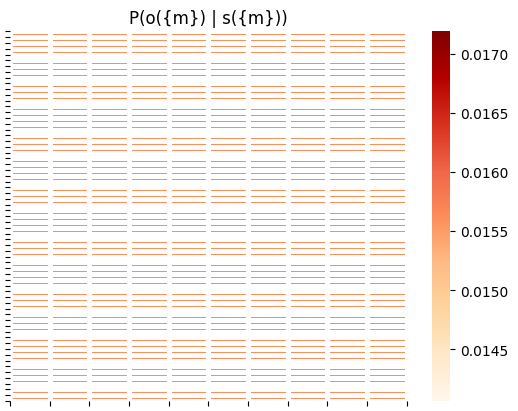

A[1]


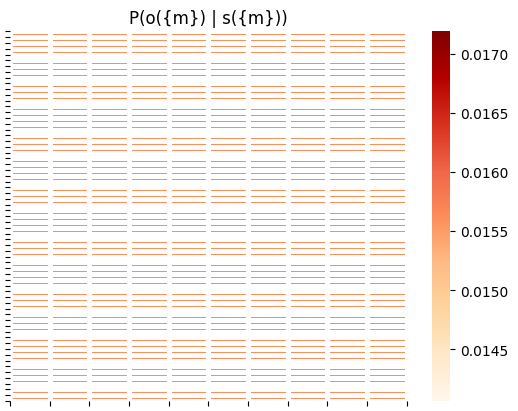

A[2]


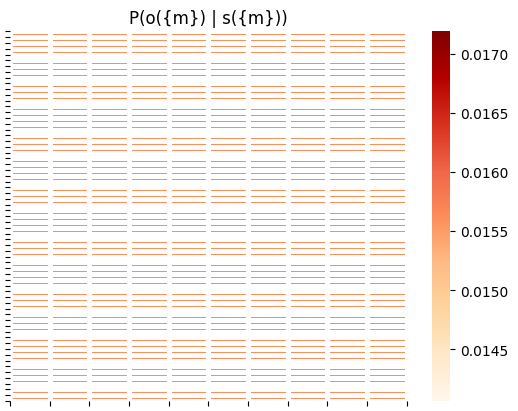

A[3]


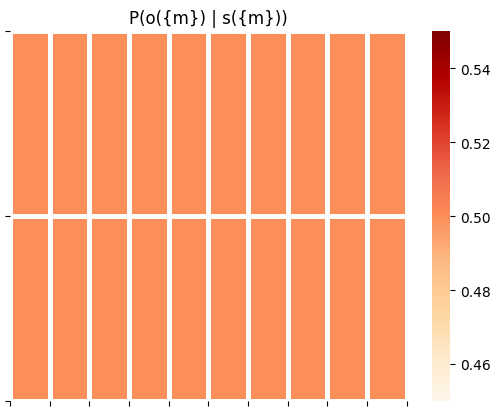

In [23]:
""" Build an object array for A matrices """

#A_m_shapes = [ [o_dim] + num_states for o_dim in num_obs] # list of shapes of modality-specific A[m] arrays
#A = utils.obj_array_zeros(A_m_shapes) # initialize A array to an object array of all-zero subarrays

#A = utils.initialize_empty_A(num_obs, num_states)

A = utils.random_A_matrix(num_obs, num_states)
A = A*0 + 1

# Sum of columns must be one
A = utils.norm_dist_obj_arr(A)

print(f'A is normalized : {utils.is_normalized(A)}')

for m in range(len(A)):
    print(f'A[{m}].shape : {A[m].shape}')

for m in range(len(A)):
    print(f'A[{m}]')
    utils.plot_likelihood(A[m][:,:], title = "P(o({m}) | s({m}))" )

B is normalized : True
B[0].shape : (10, 10, 2)
B[0]
action = 0


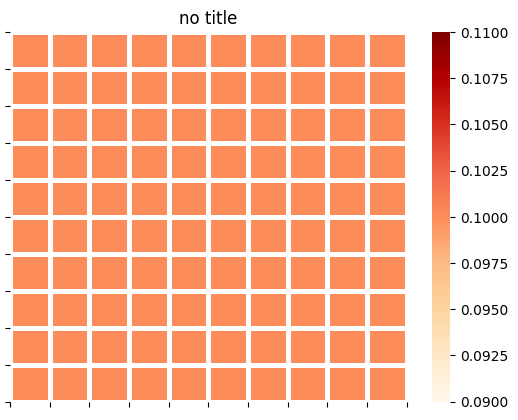

B[0]
action = 1


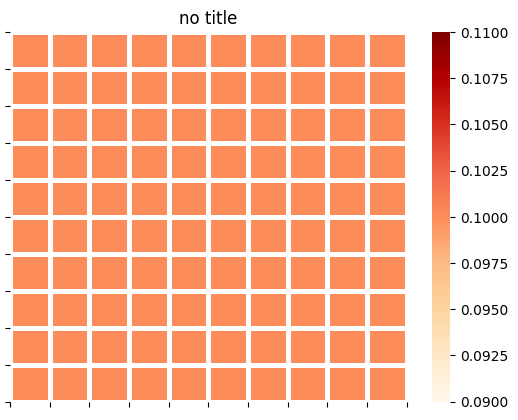

In [24]:
""" Build an object array for storing the factor-specific B matrices """

# initialize the shapes of each sub-array `B[f]`
#B_f_shapes = [ [ns, ns, num_controls[f]] for f, ns in enumerate(num_states)]

# create the `B` array and fill it out
#B = utils.obj_array_zeros(B_f_shapes)

#B = utils.initialize_empty_B(num_states, num_controls)

B = utils.random_B_matrix(num_states, num_controls)

# Uniform B
B = B*0 + 1
# Sum of columns must be one
B = utils.norm_dist_obj_arr(B)

print(f'B is normalized : {utils.is_normalized(B)}')

for f in range(len(B)):
    print(f'B[{f}].shape : {B[f].shape}')

for f,actions in enumerate(num_controls):
    for a in range(actions):
        print(f'B[{f}]')
        print(f'action = {a}')
        utils.plot_likelihood(B[f][:,:,a], title = 'no title')

In [25]:
env = TestEnv(num_obs)

intex of goal_pole_angle = 31.499999999999996


In [26]:
env.env_gym.close()  # close (close pygame window)}

softmax(C[0]) : [0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625
 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625
 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625
 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625
 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625
 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625
 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625
 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]
softmax(C[1]) : [6.73796896e-44 1.64355885e-42 4.00905038e-41 9.77907481e-40
 2.38536050e-38 5.81848980e-37 1.41927493e-35 3.46196590e-34
 8.44459917e-33 2.05984857e-31 5.02448494e-30 1.22559732e-28
 2.98953786e-27 7.29222923e-26 1.77875677e-24 4.33883186e-23
 1.05834942e-21 2.58157846e-20 6.29711440e-19 1.53602342e-17
 3.74674462e-16 9.13924556e-15 2.22929017e-13 5.43779530e-12
 1.32641404e-10 3

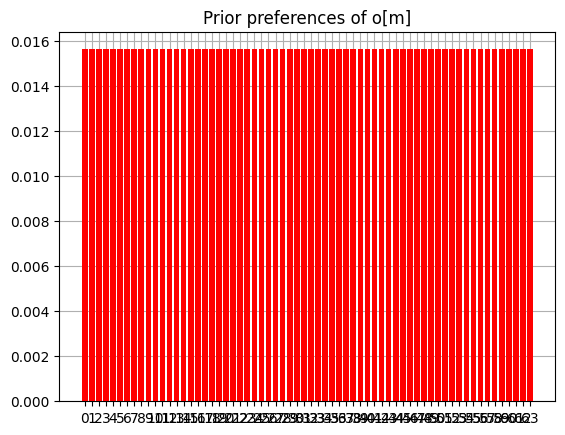

softmax(C[1])


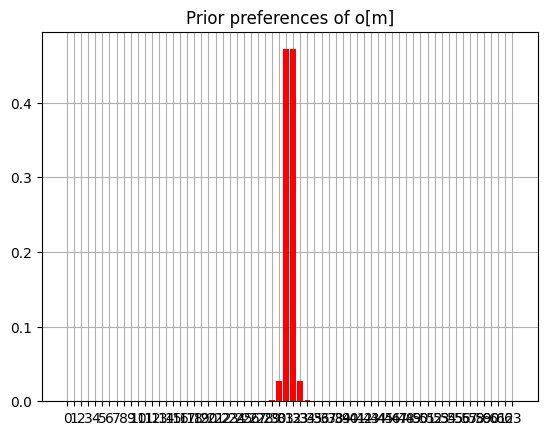

softmax(C[2])


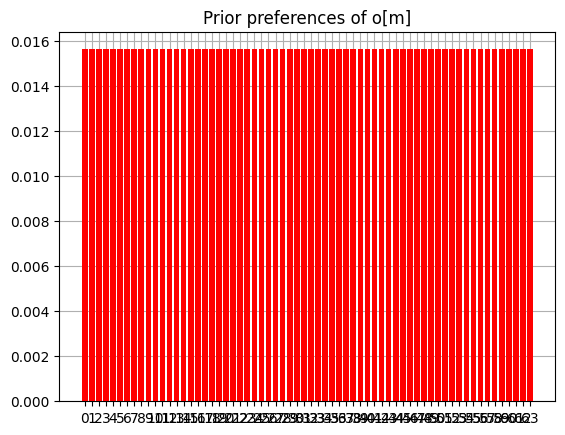

softmax(C[3])


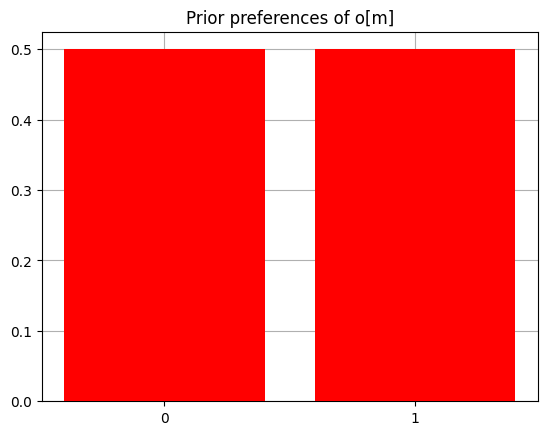

log(softmax(C[0]))


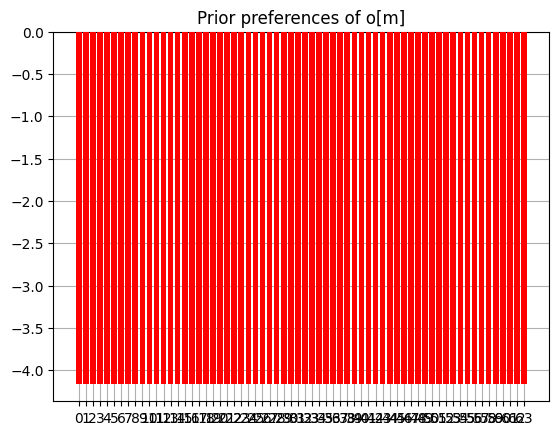

log(softmax(C[1]))


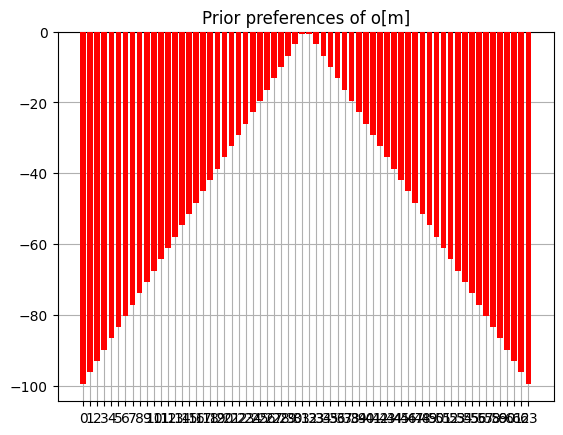

log(softmax(C[2]))


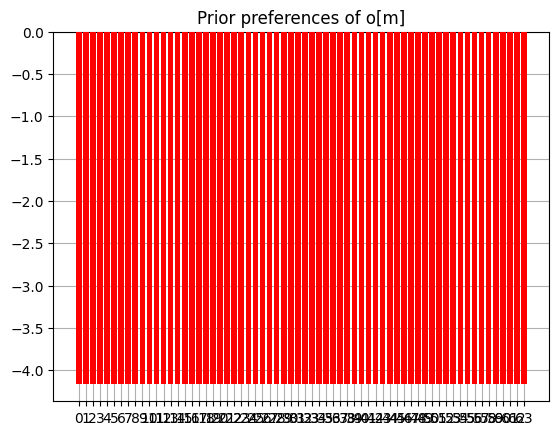

log(softmax(C[3]))


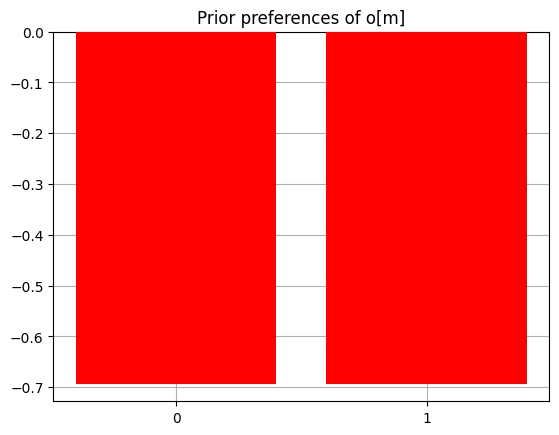

In [27]:
from pymdp.legacy.maths import softmax

goal_pole_angle = env.goal_pole_angle # index @ pole angle = 0[deg]

def create_C(sigma=1.):

    C = utils.obj_array_zeros(num_obs)
    #C = utils.obj_array_uniform(num_obs)

    x = np.linspace(0, obs_division-1, obs_division)
    # C[1] = np.log(np.exp(-(x-goal_pole_angle)**2 / (2 * sigma**2)) / np.sqrt(2 * np.pi * sigma**2))

    # parameters of logistic distribution
    mu = goal_pole_angle  # location parameter
    s = sigma*0.5513*0.25 # scale parameter #　σ^2 = π^2 * s^2 / 3 →　s = sqrt(3)*σ/π = 0.5513*σ
    # probability density function of logistic distribution
    z = (x - mu) / s
    C[1] = np.log((np.exp(-z) / (s * (1 + np.exp(-z))**2)))

    #C[1] = np.log(1e-128 + utils.onehot(int(goal_pole_angle), obs_division))

    return C

C = create_C(sigma=1.7/(env.pole_angle_max*180/3.14159)*(num_obs[1]/2)) # sigma=1.7deg

# print(f'C : {C}')

for m in range(len(C)):
    print(f'softmax(C[{m}]) : {softmax(C[m])}')

for m in range(len(C)):
    print(f'softmax(C[{m}])')
    utils.plot_beliefs(softmax(C[m]), title = "Prior preferences of o[m]")

# for m in range(len(C)):
#     print(f'C[{m}]')
#     utils.plot_beliefs(C[m], title = "Prior preferences of o[m]")

# pymdp JAX does not apply softmax and ln to C in compute_expected_utility (control.py)
for m in range(len(C)):
    C[m] = np.log(softmax(C[m]))

for m in range(len(C)):
    print(f'log(softmax(C[{m}]))')
    utils.plot_beliefs(C[m], title = "Prior preferences of o[m]")


x : [-4.5 -3.5 -2.5 -1.5 -0.5  0.5  1.5  2.5  3.5  4.5]
D[0] : [0.00359724 0.00853025 0.01955452 0.04172171 0.07813649 0.12186351
 0.15827829 0.18044548 0.19146975 0.19640276]
D[0]


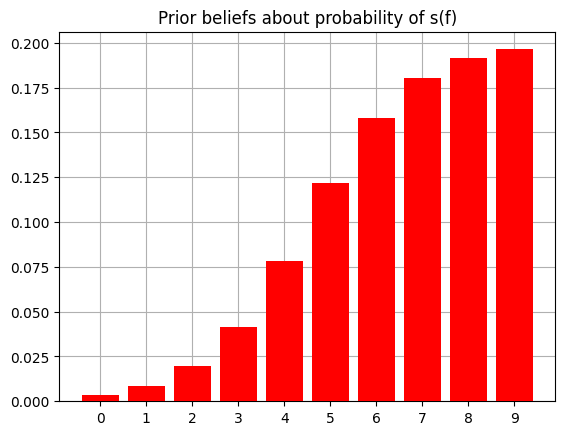

In [28]:
#D[0] = np.ones(num_states[0]) / (num_states[0])
D = utils.obj_array_uniform(num_states)

#D[0] = utils.onehot(0, num_states)

#D = utils.random_single_categorical(num_states)

##D[0] = softmax(np.log(np.linspace(1e-16, num_states[0]-1, num_states[0])))
#D[0] = softmax(np.log(np.linspace(1, num_states[0], num_states[0])))

a = 4.0 / ((int(num_states[0])-1)/2)
x = np.linspace(0, int(num_states[0])-1, int(num_states[0])) - (int(num_states[0])-1)/2
print(f'x : {x}')
D[0] = softmax(np.log(1/(1+np.exp(-a*x))))

for f in range(len(D)):
    print(f'D[{f}] : {D[f]}')
    print(f'D[{f}]')
    utils.plot_beliefs(D[f], title = "Prior beliefs about probability of s(f)")

In [29]:
total_combinations = np.prod(num_obs)
print(f'Total number of observation combinations: {total_combinations}')

total_elements_A = sum(a.size for a in A)
print(f'Total number of elements in A tensor: {total_elements_A}')

total_elements_B = sum(b.size for b in B)
print(f'Total number of elements in B tensor: {total_elements_B}')

観測値の組み合わせ総数: 524288
Aテンソルの要素数の合計: 1940
Bテンソルの要素数の合計: 200


In [30]:
pA = utils.dirichlet_like(A, scale = 1e-2)
pB = utils.dirichlet_like(B, scale = 1e-2)

# Convert each element of pA and pB to float32 JAX arrays
pA = [jnp.array(item, dtype=jnp.float32) for item in pA]
pB = [jnp.array(item, dtype=jnp.float32) for item in pB]

## Now let's take advantage of the `Agent` class in `pymdp` to wrap this all into an Agent instance that we can use to do active inference in a few lines.

In [31]:
from functools import partial
from equinox import tree_at

batch_size =  1 #1 # number of agents
policy_length = 2
inference_horizon = 8 #32
learn_D = True

A_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(A))
B_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(B))
C_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(C))
D_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(D))
# E_jax = jnp.ones((batch_size, length_of_policies))/ length_of_policies

pA_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(pA))
pB_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(pB))

import pickle
### to use saved pA, pB, D ###
# with open("agents_pA.pickle", "rb") as f1:
#     pA_jax = pickle.load(f1)

# with open("agents_pB.pickle", "rb") as f2:
#     pB_jax = pickle.load(f2)

# with open("agents_D.pickle", "rb") as f3:
#     D_jax = pickle.load(f3)

@partial(jit, static_argnames=['batch_size'])
def update_outcomes(agents, obs, outcomes, batch_size=1):

    outcome_t = jtu.tree_map(lambda x: jnp.broadcast_to(jnp.expand_dims(x, -1), (batch_size,) + x.shape), obs)
    if agents.categorical_obs == True:
        outcome_t = [nn.one_hot(o, agents.num_obs[m]) for m, o in enumerate(outcome_t)] # one-hot encode outcomes_t
    # print(f'    outcome_t at time {T}: {outcome_t}')

    if outcomes is None:
        outcomes = outcome_t
    else:
        outcomes = jtu.tree_map(lambda prev_o, new_o: jnp.concatenate([prev_o, new_o], axis=1), outcomes, outcome_t)
    # print(f'    outcomes at time {T}: {outcomes}')

    return outcomes

@partial(jit, static_argnames=['batch_size','inference_horizon'])
def update_agent(agents, outcomes, actions, infer_args, batch_keys, batch_size=1, inference_horizon=1000):

    ### Start of Active inference roop ##

    beliefs = agents.infer_states(outcomes, infer_args[0], past_actions=actions, qs_hist=None)
    vfe = [np.array(0)] # Dummy value if you don't calculate vfe.
    # beliefs, vfe = agents.infer_states_vfe(outcomes, infer_args[0], past_actions=actions, qs_hist=None)
    # print(f'    beliefs at time {T}: {beliefs}')
    # print(f'    vfe at time {T}: {vfe}')

    q_pi, neg_efe = agents.infer_policies(beliefs)
    # print(f'    q_pi at time {T}: {q_pi}')
    # print(f'    neg_efe at time {T}: {neg_efe}')

    batch_keys = jr.split(batch_keys[0], batch_size)
    actions_t = agents.sample_action(q_pi, rng_key=batch_keys)
    # actions_t = jnp.array([[env.env_gym.action_space.sample()]]) # random actions for debug
    # print(f'    actions_t at time {T}: {actions_t}')

    if actions is not None:
        actions = jnp.concatenate([actions, jnp.expand_dims(actions_t, -2)], -2)
    else:
        actions = jnp.expand_dims(actions_t, -2)
    # print(f'    actions at time {T}: {actions}')

    # restrict number of the history
    outcomes = jtu.tree_map( lambda x: x[:, -inference_horizon:], outcomes)
    # print(f'    outcomes at time {T}: {outcomes}')
    beliefs = jtu.tree_map( lambda x: x[:, -inference_horizon:], beliefs)
    # print(f'    beliefs at time {T}: {beliefs}')
    actions = jtu.tree_map( lambda x: x[:,-inference_horizon:], actions)
    # print(f'    actions at time {T}: {actions}')

    agents = tree_at(lambda x: x.D, agents, jtu.tree_map(lambda x: x[:, 0], beliefs)) # update D only when you restrict inference_horizon less than total time steps.

    infer_args = agents.update_empirical_prior(actions_t, beliefs)
    # print(f'    infer_args at time {T}: {infer_args}')

    # Learning #

    # beliefs_last = jtu.tree_map( lambda x: x[:, -1:], beliefs) # take the last belief
    # # print(f'    beliefs_last at time {T}: {beliefs_last}')
    
    # outcomes_last = jtu.tree_map( lambda x: x[:, -1:], outcomes) # take the last outcome
    # # print(f'    outcomes_last at time {T}: {outcomes_last}')

    # actions_last_pair = jtu.tree_map( lambda x: x[:,-2:], actions) # take the last two action
    # # print(f'    actions_last_pair at time {T}: {actions_last_pair}')

    # beliefs_last_pair = jtu.tree_map( lambda x: x[:, -2:], beliefs) # take the last two beliefs
    # # print(f'    beliefs_last_pair at time {T}: {beliefs_last_pair}')

    # agents = agents.infer_parameters(beliefs_last, outcomes_last, actions_last_pair, beliefs_B=beliefs_last_pair, lr_pA=1.0, lr_pB=1.0)

    return agents, outcomes, actions, infer_args, batch_keys, neg_efe, vfe

@jit
def update_parameters(agents, infer_args, outcomes, actions, lr=1.0):

    agents = agents.infer_parameters(infer_args[1], outcomes, actions, beliefs_B=infer_args[1], lr_pA=lr, lr_pB=lr)

    return agents


env = TestEnv(num_obs)

batch_keys = jr.split(jr.PRNGKey(0), batch_size)

T_episode_maxes = []

efe_means = []
vfe_means = []


for episode in range(400):

    print(f'episode : {episode}')

    env.reset()

    efes = []
    vfes = []
    outcomes_all = []
    infer_args_1_all = []
    actions_all = []
    
    if episode==0: # define your agents
        agents = AIFAgent(
            A=A_jax, 
            B=B_jax, 
            C=C_jax, 
            D=D_jax, 
            E=None, 
            pA=pA_jax, 
            pB=pB_jax, 
            learn_A=True, 
            learn_B=True, 
            learn_C=False, 
            learn_D=learn_D, 
            learn_E=False, 
            A_dependencies=None, 
            B_dependencies=None, 
            gamma=1., 
            alpha=1., 
            inference_algo="mmp", 
            action_selection="stochastic", 
            policy_len=policy_length, 
            use_utility=True, 
            use_states_info_gain=True, 
            use_param_info_gain=True, 
            use_inductive=False, 
            categorical_obs=True, #False, 
            sampling_mode="full", 
            num_iter=max(16,inference_horizon),
            # policies=np.array([[[i] for _ in range(3)] for i in range(action_division)]),
            batch_size=batch_size,
            # learning_mode="online"
        )

    # Dummy D-learning
    if episode == 0:
        pD = [0 * D for D in agents.D]  # initialize D for all factors at once
        qs_t0 = [0 * D for D in agents.D]
        D_learned = [0 * D for D in agents.D]
    else:
        for i in range(len(pD)):
            pD[i] = pD[i] + qs_t0[i] # accumulate per-episode qs[t=0] obtained by MMP
            # print(f'    qs_t0[{i}] in episode={episode} : {qs_t0[i]} ')
            # print(f'    pD[{i}] : {pD[i]}')
            D_learned[i] = pD[i] / pD[i].sum(axis=1, keepdims=True) # normalize so the element sum is 1
            # print(f'    D_learned[{i}] : {D_learned[i]}')
        if learn_D :
            agents = tree_at(lambda x: x.D, agents, D_learned)
        else :
            agents = tree_at(lambda x: x.D, agents, D_jax) # no D-learning

    for T in range(500):

        # print(f'T = {T} in episode {episode}')

        ### initialization of Active inference roop ###

        if T == 0:
            actions_t = None # no action available at the first time step
            actions = None # no action available at the first time step
            outcomes = None
            infer_args = (agents.D, None,)

        ### get observation and done condition from environment ###

        obs, done = env.step(actions_t)
        # print(f'    obs at time {T}: {obs}')
        # print(f'    is_done at time {T}: {done}')

        outcomes = update_outcomes(agents, obs, outcomes, batch_size=batch_size)

        agents, outcomes, actions, infer_args, batch_keys, neg_efe, vfe = update_agent(
            agents, 
            outcomes, 
            actions, 
            infer_args, 
            batch_keys,
            batch_size=batch_size,
            inference_horizon=inference_horizon
        )

        # print(f'    infer_args[1] : {infer_args[1]}')

        if T < inference_horizon:
            for i in range(len(qs_t0)):
                qs_t0[i] = infer_args[1][i][:, 0]  # snapshot of s[t=0] for D-learning
                # print(f'    qs_t0[{i}] at T={T} in episode={episode} : {qs_t0[i]} ')

        if T % inference_horizon == 0 or (T < inference_horizon and done): # learn when T==0 or T is a multiple of inference_horizon, or when T < inference_horizon and done is True
            agents = update_parameters(agents, infer_args, outcomes, actions, lr=1.0)               

        efe_batch0 = np.array(-neg_efe[0]) # efe for batch=0
        # print(f'    efe at time {T}: {efe}')
        efes.append(efe_batch0)
        # print(f'    efes at time {T}: {efes}')
        vfe_batch0 = np.array(vfe[0]) # vfe for batch=0
        vfes.append(vfe_batch0)
        # print(f'    vfes at time {T}: {vfes}')

        outcomes_last = jtu.tree_map(lambda x: x[:, -1:], outcomes)
        outcomes_all.append(outcomes_last)

        infer_args_1_last = jtu.tree_map(lambda x: x[:, -1:], infer_args[1])
        infer_args_1_all.append(infer_args_1_last)

        actions_last = jtu.tree_map(lambda x: x[:, -1:], actions)
        actions_all.append(actions_last)
            
        actions_t = actions[:,-1]
        # print(f'    actions at time {T}: {actions}')
        # print(f'    actions_t at time {T}: {actions_t}')

        ### End of Active inference roop ###
        if done or T==499:
            # end one episode when done is True

            ### save pA, pB, D as pickle ###
            # agents_pA = agents.pA
            # agents_pB = agents.pB
            # agents_D = agents.D
            # with open("agents_pA.pickle", "wb") as f1:
            #     pickle.dump(agents_pA, f1)
            # with open("agents_pB.pickle", "wb") as f2:
            #     pickle.dump(agents_pB, f2)
            # with open("agents_D.pickle", "wb") as f3:
            #     pickle.dump(agents_D, f3)

            T_episode_maxes.append(env.T_episode_max)
            efe_mean = np.mean(np.array(efes), axis=0)
            efe_means.append(efe_mean) # efe average over time steps
            print(f'efe_mean in episode {episode}: {efe_mean}')
            vfe_mean = np.mean(np.array(vfes), axis=0)
            vfe_means.append(vfe_mean) # vfe average over time steps
            print(f'vfe_mean in episode {episode}: {vfe_mean}')

            break

env.env_gym.close()  # close (close pygame window)

intex of goal_pole_angle = 31.499999999999996
episode : 0


/var/folders/_f/1qqqnkyd5k5g2b1pgfwzzrqm0000gn/T/ipykernel_87603/2329320056.py:133: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agents = AIFAgent(


    T_env = 0
    T_env = 1
    T_env = 2
    T_env = 3
    T_env = 4
    T_env = 5
    T_env = 6
    T_env = 7
    T_env = 8
    T_env = 9
    T_env = 10
    T_env = 11
    T_env = 12
    T_env = 13
    T_env = 14
    T_episode_max : 14
T_max : 14
efe_mean in episode 0: [36.517776 36.861465 37.258194 37.388504]
vfe_mean in episode 0: 0.0
episode : 1
    T_env = 0
    T_env = 1
    T_env = 2
    T_env = 3
    T_env = 4
    T_env = 5
    T_env = 6
    T_env = 7
    T_env = 8
    T_env = 9
    T_episode_max : 9
T_max : 14
efe_mean in episode 1: [18.05572  19.417507 19.882114 21.486868]
vfe_mean in episode 1: 0.0
episode : 2
    T_env = 0
    T_env = 1
    T_env = 2
    T_env = 3
    T_env = 4
    T_env = 5
    T_env = 6
    T_env = 7
    T_env = 8
    T_env = 9
    T_env = 10
    T_env = 11
    T_env = 12
    T_env = 13
    T_env = 14
    T_env = 15
    T_env = 16
    T_env = 17
    T_env = 18
    T_env = 19
    T_env = 20
    T_env = 21
    T_env = 22
    T_env = 23
    T_env = 24
    T

In [32]:
env.env_gym.close()  # close (close pygame window)}

In [33]:
np.mean(T_episode_maxes)

np.float64(82.3475)

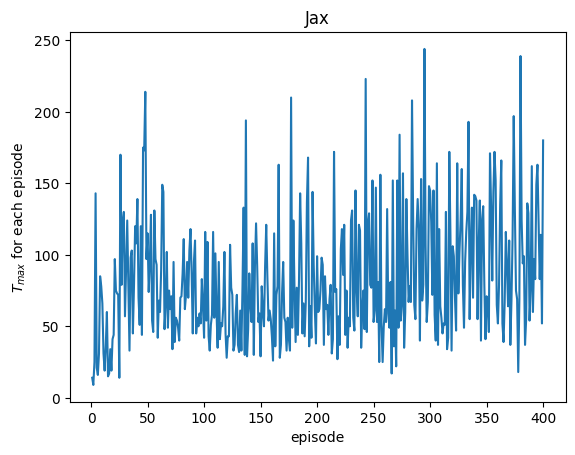

In [34]:
plt.plot(range(1, len(T_episode_maxes) +1), T_episode_maxes)
plt.ylabel(r"$T_{max}$ for each episode")
plt.xlabel('episode')
plt.title('Jax');

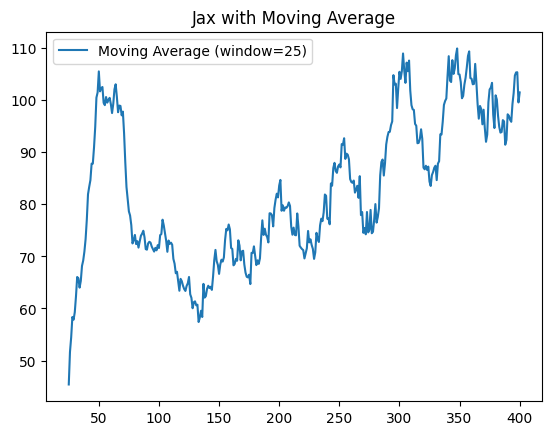

In [51]:
# Moving average of T_episode_maxes
window_size = 25
T_episode_maxes_ma = np.convolve(T_episode_maxes, np.ones(window_size)/window_size, mode='valid')
plt.plot(range(window_size, len(T_episode_maxes) +1), T_episode_maxes_ma, label=f'Moving Average (window={window_size})')
plt.legend()
plt.title('Jax with Moving Average');

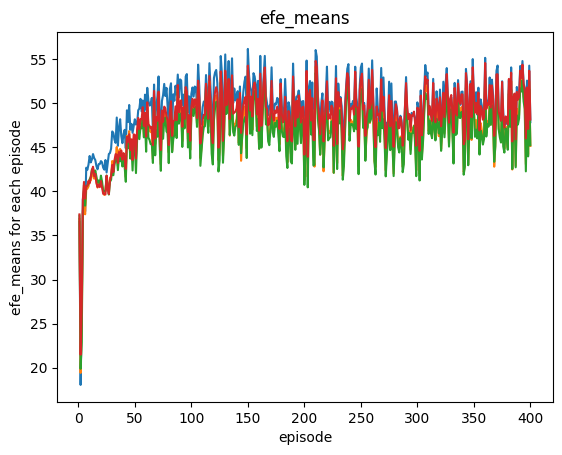

In [35]:
plt.plot(range(1, len(efe_means) +1), efe_means)
plt.ylabel(r"efe_means for each episode")
plt.xlabel('episode')
plt.title('efe_means');

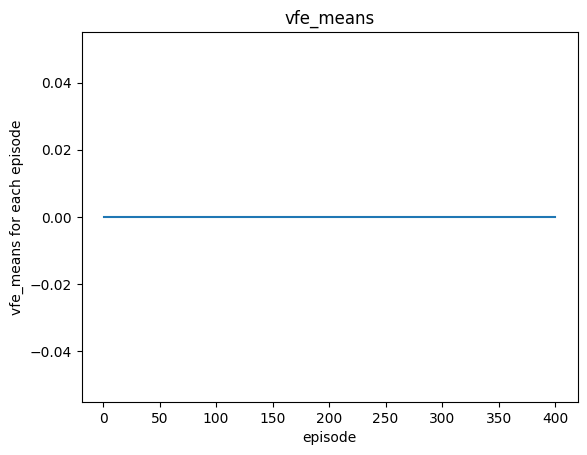

In [36]:
plt.plot(range(1, len(vfe_means) +1), vfe_means)
plt.ylabel(r"vfe_means for each episode")
plt.xlabel('episode')
plt.title('vfe_means');

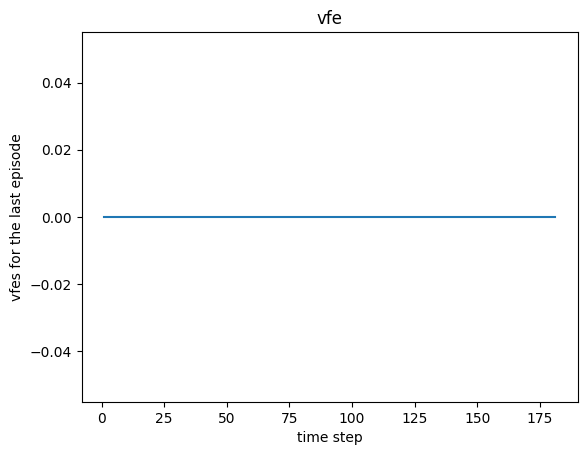

In [37]:
plt.plot(range(1, len(vfes) +1), vfes)
plt.ylabel(r"vfes for the last episode")
plt.xlabel('time step')
plt.title('vfe');

modality = 0


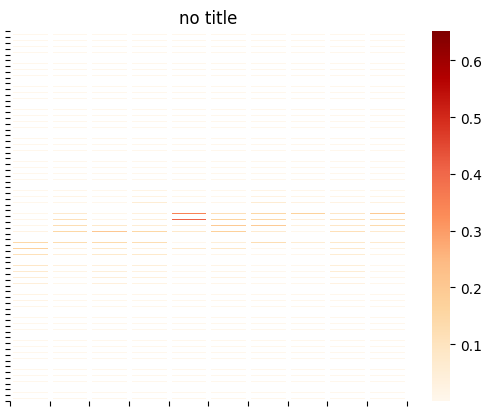

modality = 1


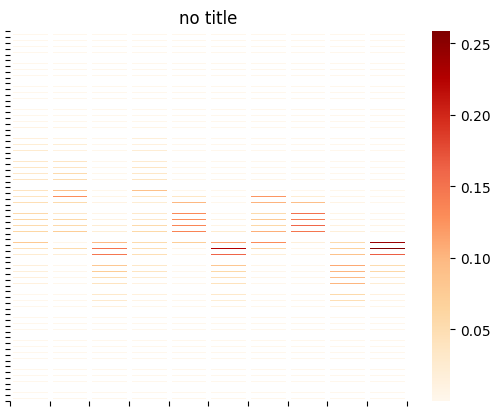

modality = 2


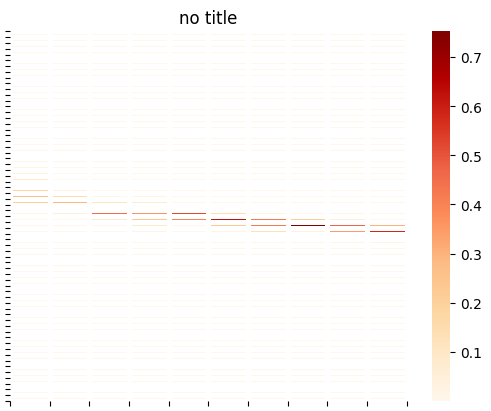

modality = 3


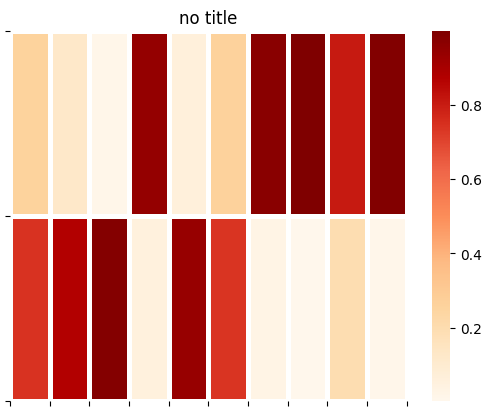

In [38]:
batch_num = 0
for m in range(len(agents.A)):
    print(f'modality = {m}')
    utils.plot_likelihood(agents.A[m][batch_num,:,:], title = 'no title')

factor = 0
actions = 0


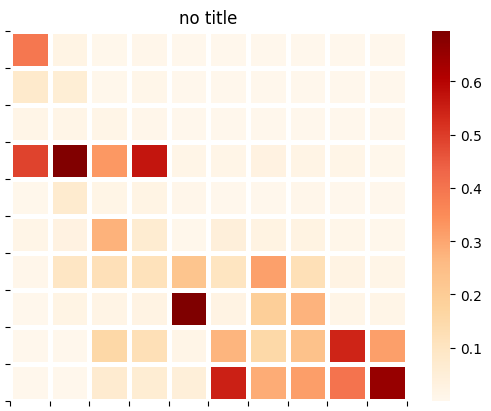

factor = 0
actions = 1


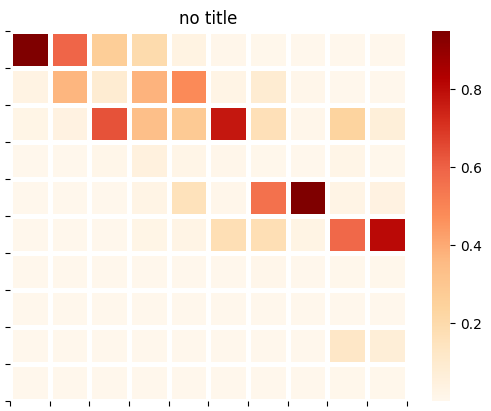

In [39]:
batch_num = 0
for f in range(len(agents.B)):
    for a in range(num_controls[f]):
        print(f'factor = {f}')
        print(f'actions = {a}')
        utils.plot_likelihood(agents.B[f][batch_num,:,:,a], title = 'no title')

In [40]:
def stack_tree_list(tree_list):
    # tree_list: [tree, tree, ...] each tree has the same structure
    # stack each leaf along axis=1
    return jtu.tree_map(lambda *xs: jnp.concatenate(xs, axis=1), *tree_list)

outcomes_all = stack_tree_list(outcomes_all)
actions_all = stack_tree_list(actions_all)
infer_args_1_all = stack_tree_list(infer_args_1_all)
infer_args_all = [qs_t0, infer_args_1_all]

outcomes = outcomes_all
infer_args = infer_args_all
actions = actions_all

In [41]:
from pymdp import maths

In [42]:
len(outcomes[0][0])

181

In [43]:
len(infer_args[1][0][0])

181

In [44]:
len(actions[0])

181

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def plot_obs_vs_pred(qo_list, outcomes_list, categorical_obs, T_range=None, modality=0):
    """
    qo_list: list of inferred values at each time [T][observation dimension]
    outcomes_list: list of actual observations at each time [T][observation dimension] or indices
    categorical_obs: one-hot flag
    T_range: tuple of (T_start, T_end). If None, use all timesteps
    modality: modality index to visualize
    """
    # --- apply time range ---
    if T_range is not None:
        t_start, t_end = T_range
        qo_list       = qo_list[t_start:t_end]
        outcomes_list = outcomes_list[t_start:t_end]

    # --- matrixize inferred values (obs_dim × T) ---
    qo_arr = np.stack([np.array(qo[modality]) for qo in qo_list], axis=1)

    # --- get indices of actual observations ---
    obs_indices = []
    for out in outcomes_list:
        if categorical_obs:
            idx = int(np.argmax(out[modality]))
        else:
            idx = int(out[modality])
        obs_indices.append(idx)

    # --- plot ---
    T = qo_arr.shape[1]
    t = np.arange(T)

    fig, ax = plt.subplots(figsize=(12, 4))
    # use 'gray_r' so high probability is black and low probability is white
    im = ax.imshow(
        qo_arr,
        aspect='auto',
        cmap='gray_r',  # set this to 'gray_r'
        vmin=0, vmax=1,
        origin='lower'   # place index 0 at the bottom
    )
    fig.colorbar(im, ax=ax, label='Predicted Probability')

    # overlay actual observations with blue points
    ax.scatter(
        t, obs_indices,
        c='blue', s=10,
        label='Actual Observations'
    )

    ax.set_xlabel('Time')
    ax.set_ylabel('Observation Index')
    ax.set_title('Predicted Values (High=Black, Low=White) and Actual Observations (Blue Dots)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

modality = 0


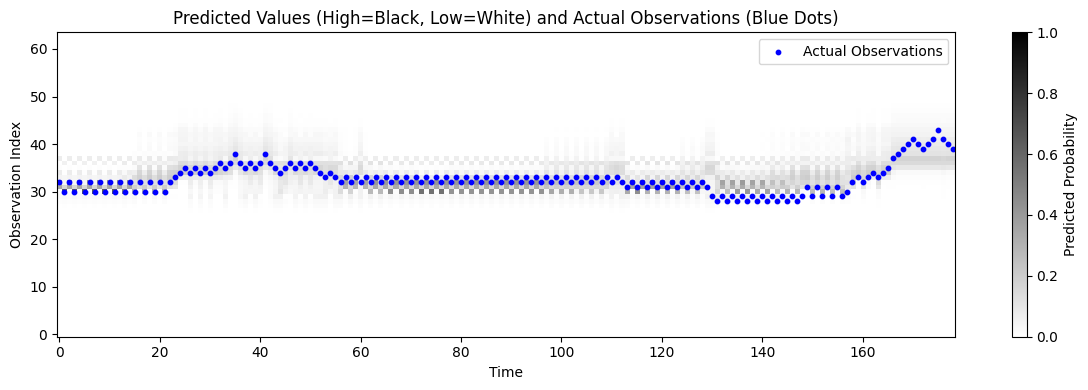

modality = 1


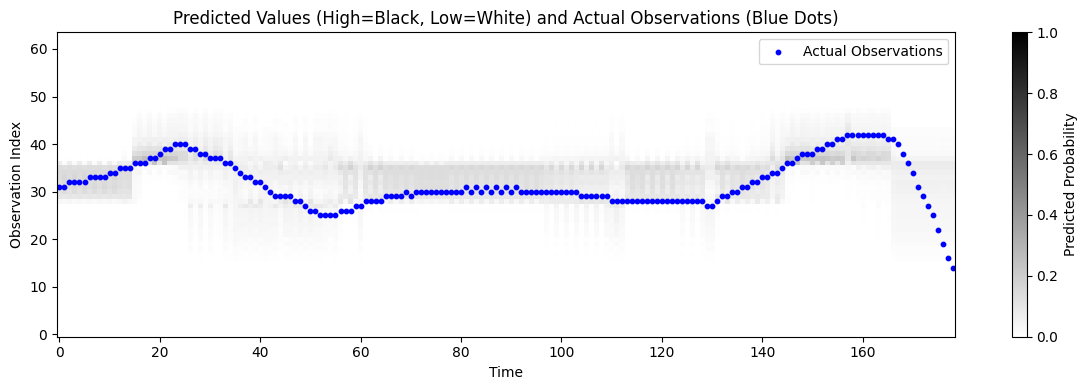

modality = 2


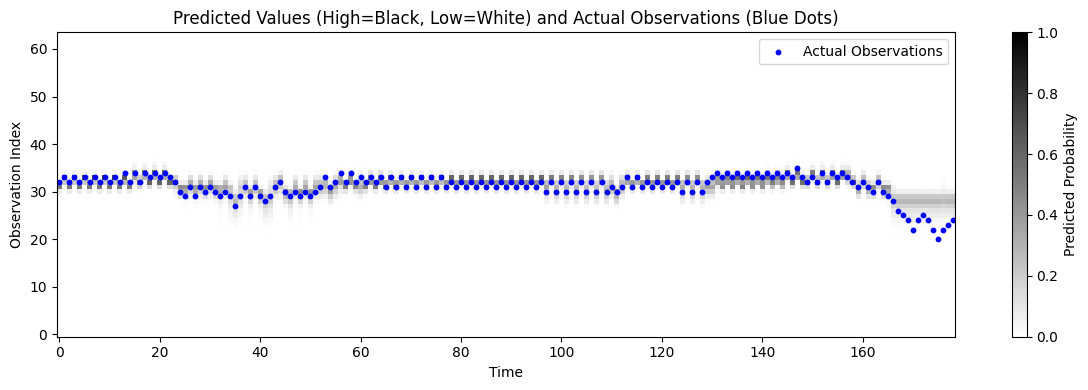

modality = 3


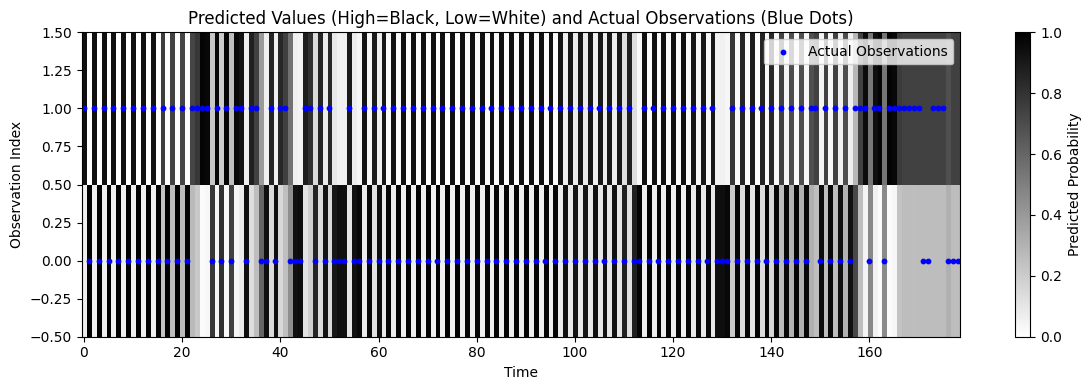

In [46]:
from pymdp.control import compute_expected_obs

qo_list = []
outcomes_list = []

T_start = 1 # >0
T_end = len(outcomes[0][0])

T_start = max(T_start, 1) # >0
# T_end = min(T_end, inference_horizon) # < inference_horizon

for T_inference in range(T_start, T_end):

    beliefs_T_inferece = jtu.tree_map( lambda x: x[:, T_inference], infer_args[1])

    # print(f"beliefs_T_inferece shape: {[b.shape for b in beliefs_T_inferece]}")
    # print(f"agents.A shape: {[a.shape for a in agents.A]}")

    batch_num = 0
    beliefs_T_inferece_selected_batch = jtu.tree_map(lambda x: jnp.take(x, batch_num, axis=0), beliefs_T_inferece)
    A_selected_batch = jtu.tree_map(lambda x: jnp.take(x, batch_num, axis=0), agents.A)
    qo = compute_expected_obs(beliefs_T_inferece_selected_batch, A_selected_batch, agents.A_dependencies)

    qo_list.append(qo)
    outcomes_list.append([outcomes[m][batch_num][T_inference] for m in range(len(qo))])

for m in range(len(qo)):
    print(f'modality = {m}')
    plot_obs_vs_pred(qo_list, outcomes_list, agents.categorical_obs, (T_start, T_end), modality=m)

In [47]:
T_start = 1 # >0
T_end = 5 # < inference_horizon

T_start = max(T_start, 1) # >0
T_end = min(T_end, inference_horizon-1) # < inference_horizon

T_inference = 1
    factor = 0


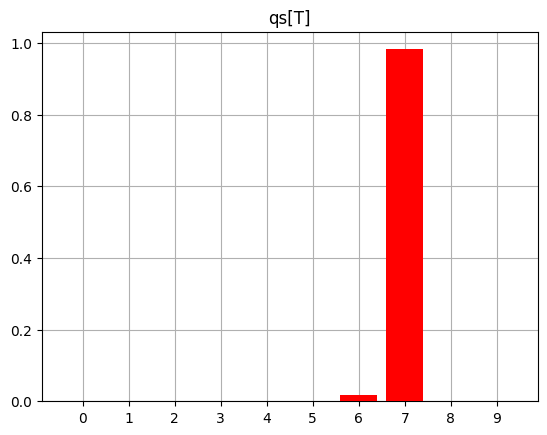

T_inference = 1
    modality = 0
    outcomes[0] = 30
    A[0]s = 30.7


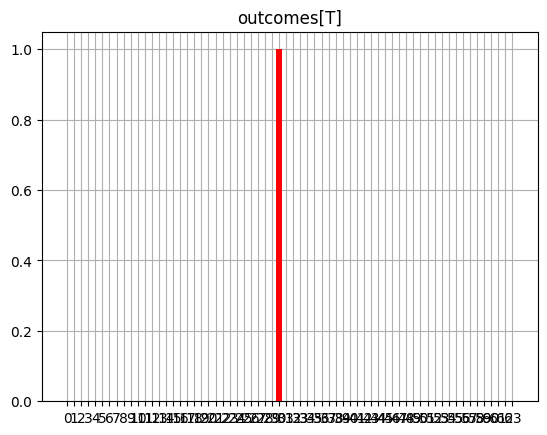

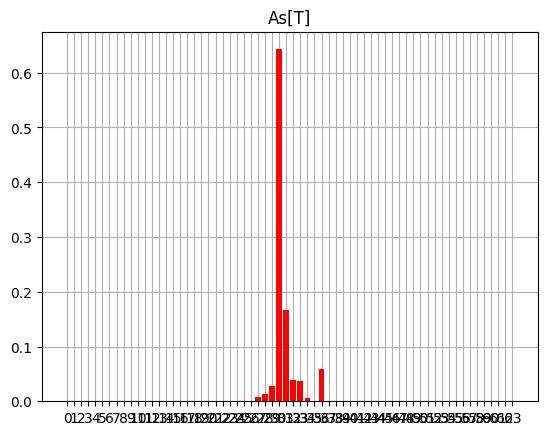

T_inference = 1
    modality = 1
    outcomes[1] = 31
    A[1]s = 32.1


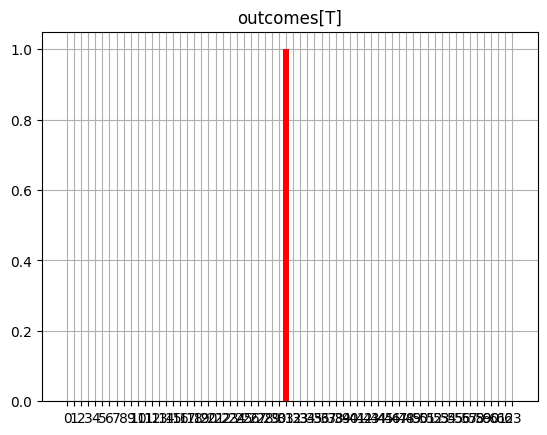

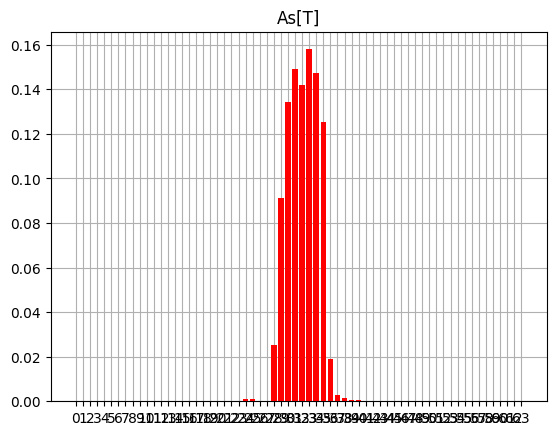

T_inference = 1
    modality = 2
    outcomes[2] = 33
    A[2]s = 32.8


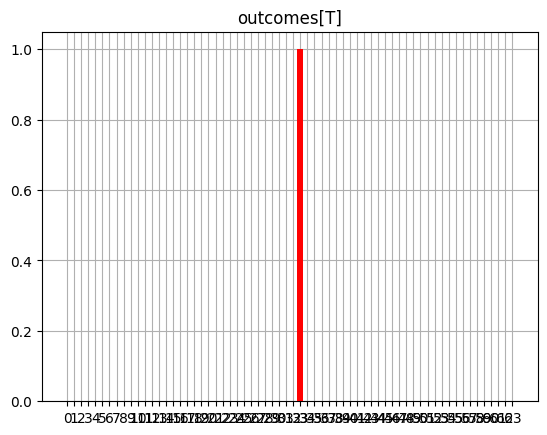

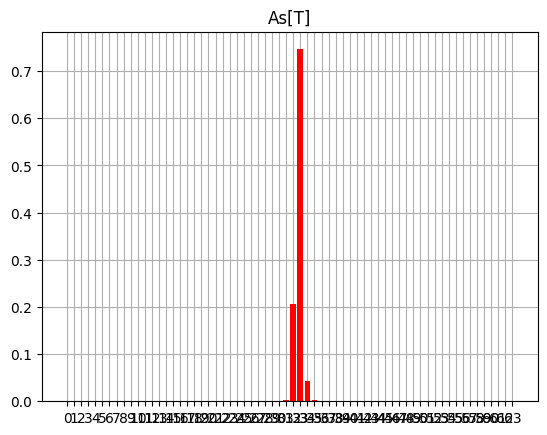

T_inference = 1
    modality = 3
    outcomes[3] = 0
    A[3]s = 0.0


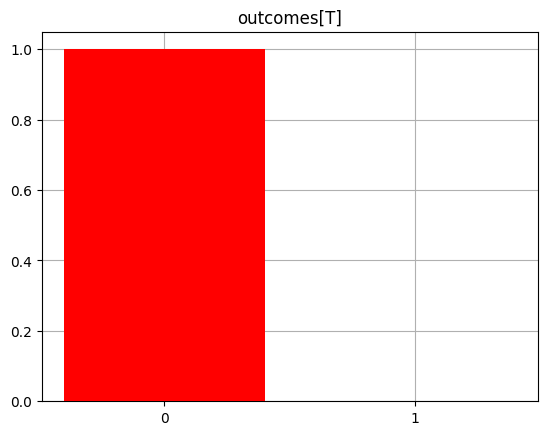

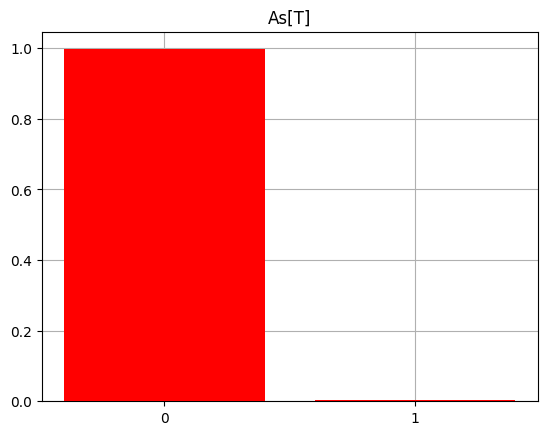

T_inference = 2
    factor = 0


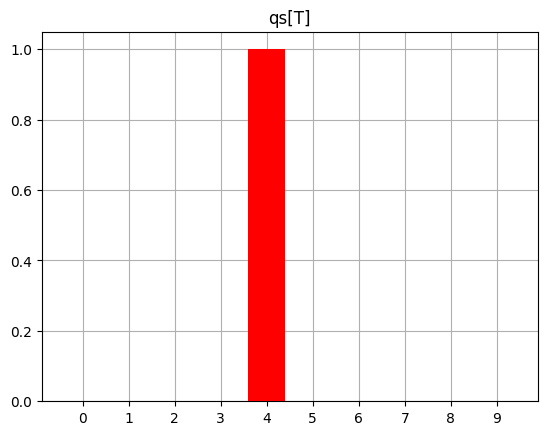

T_inference = 2
    modality = 0
    outcomes[0] = 32
    A[0]s = 32.1


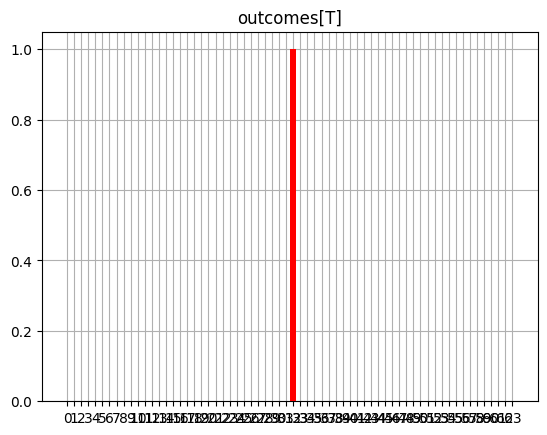

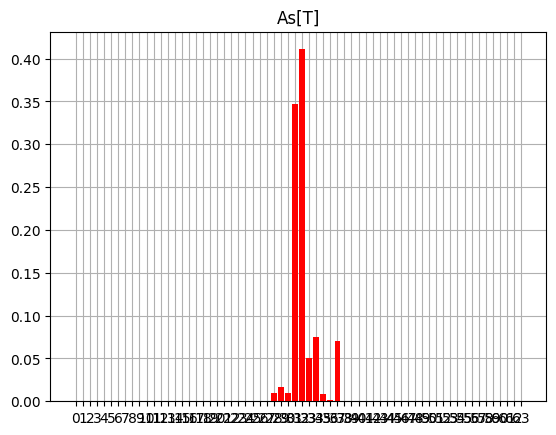

T_inference = 2
    modality = 1
    outcomes[1] = 31
    A[1]s = 32.3


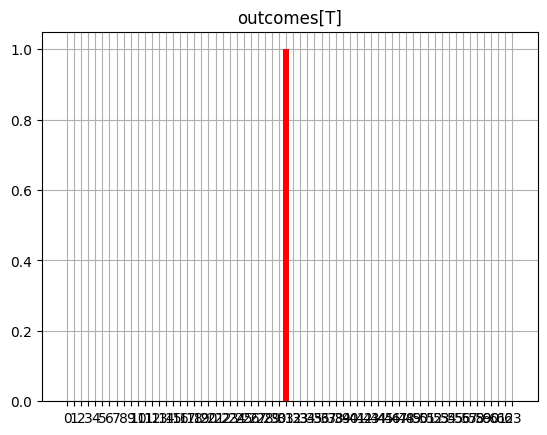

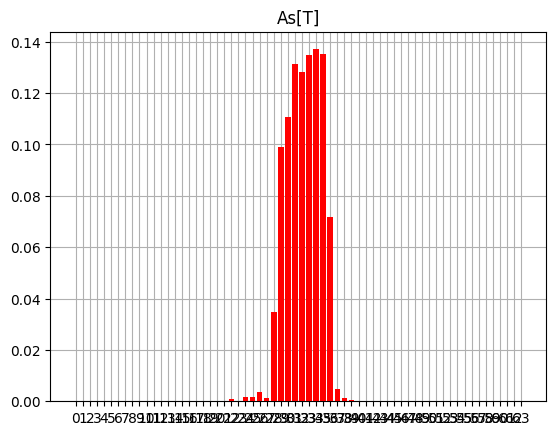

T_inference = 2
    modality = 2
    outcomes[2] = 32
    A[2]s = 31.3


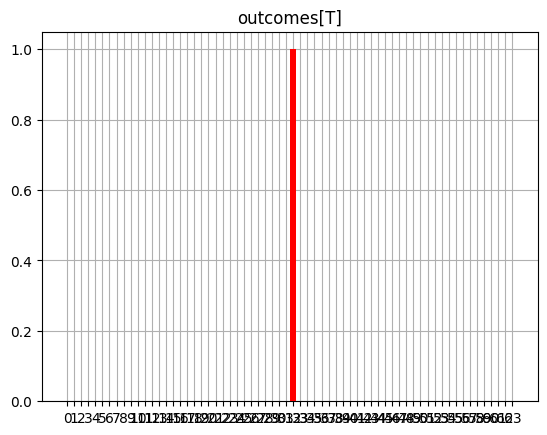

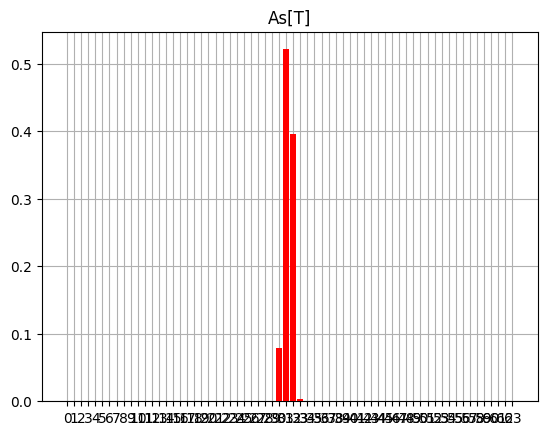

T_inference = 2
    modality = 3
    outcomes[3] = 1
    A[3]s = 0.9


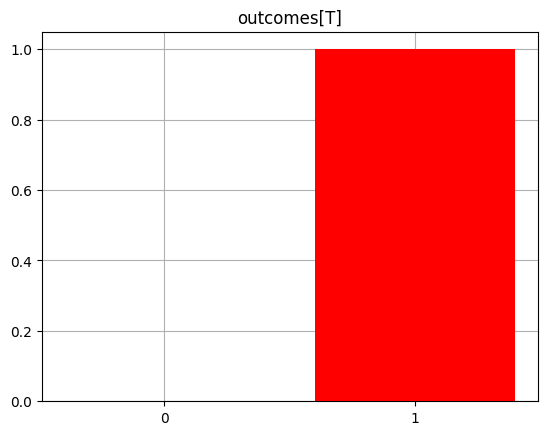

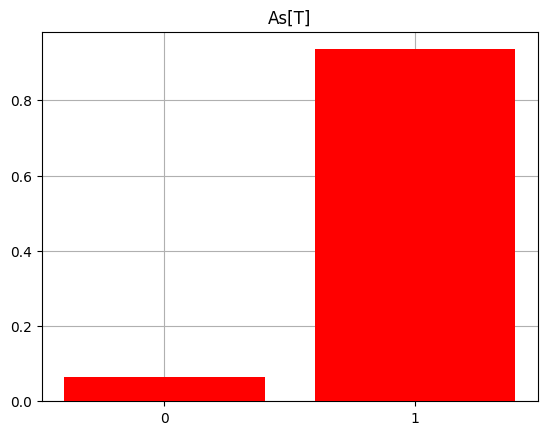

T_inference = 3
    factor = 0


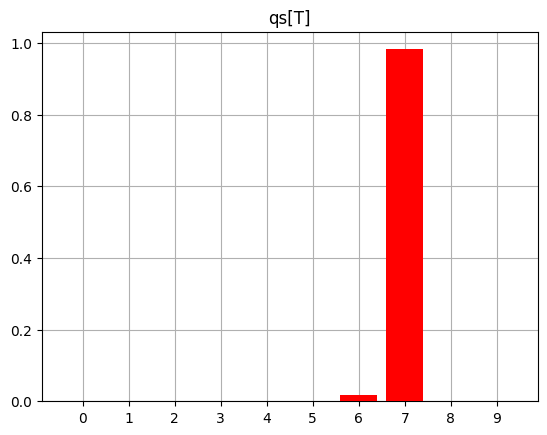

T_inference = 3
    modality = 0
    outcomes[0] = 30
    A[0]s = 30.7


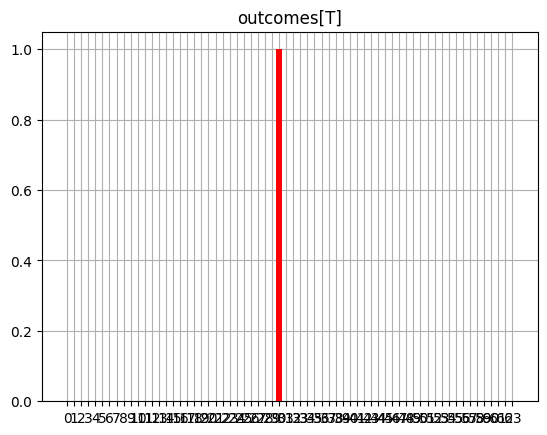

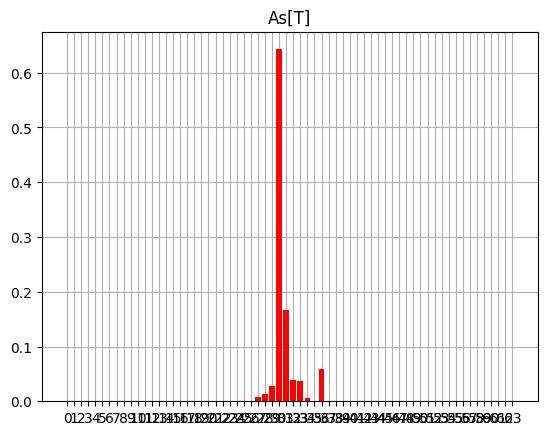

T_inference = 3
    modality = 1
    outcomes[1] = 31
    A[1]s = 32.1


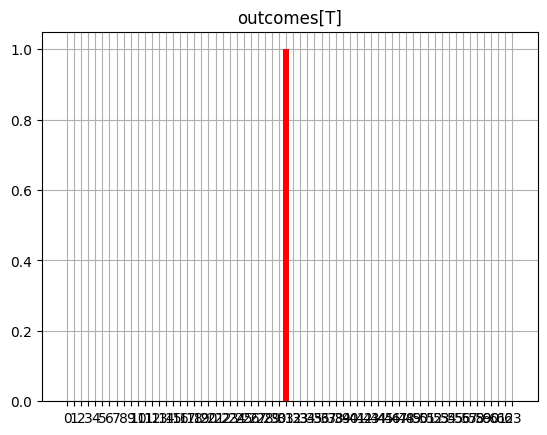

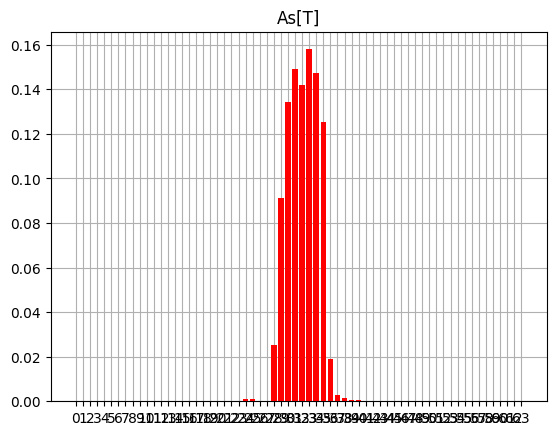

T_inference = 3
    modality = 2
    outcomes[2] = 33
    A[2]s = 32.8


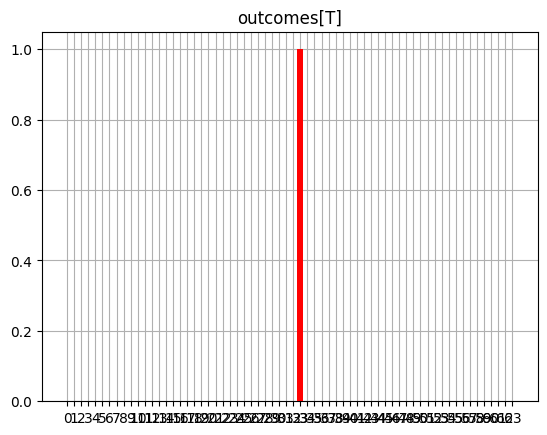

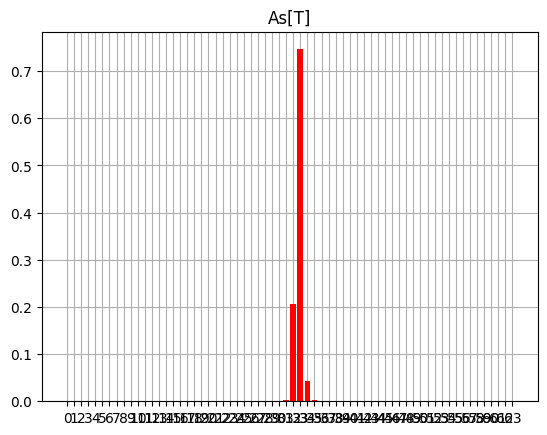

T_inference = 3
    modality = 3
    outcomes[3] = 0
    A[3]s = 0.0


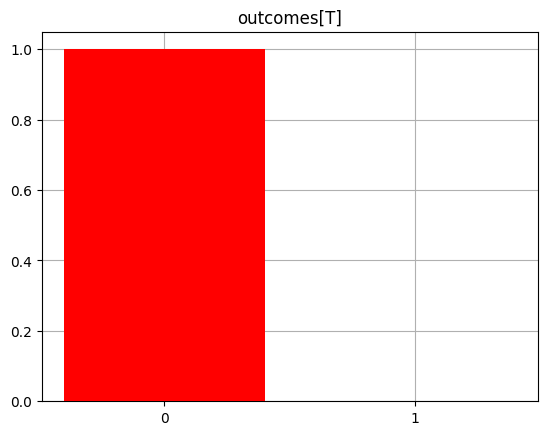

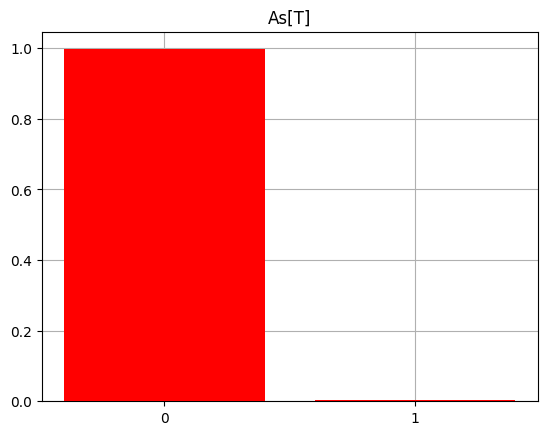

T_inference = 4
    factor = 0


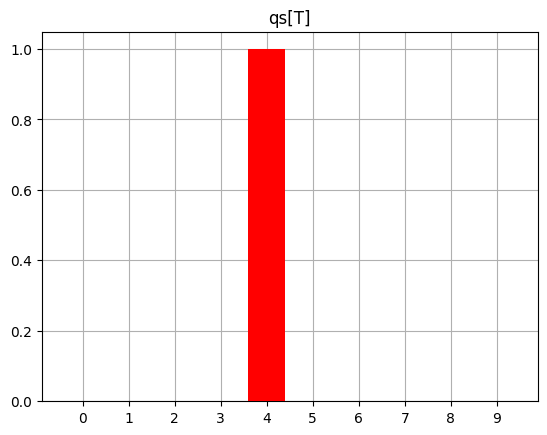

T_inference = 4
    modality = 0
    outcomes[0] = 32
    A[0]s = 32.1


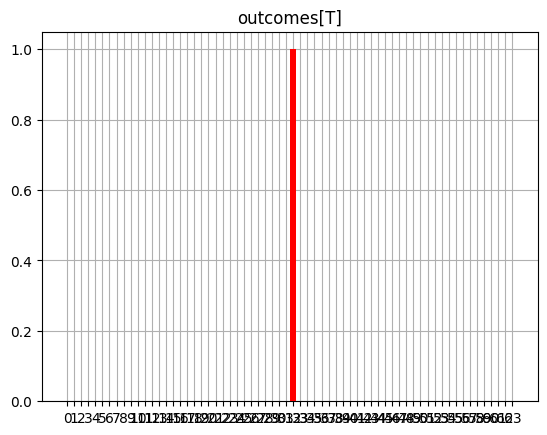

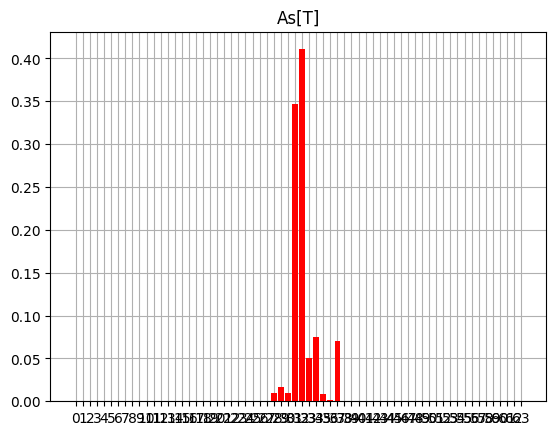

T_inference = 4
    modality = 1
    outcomes[1] = 32
    A[1]s = 32.3


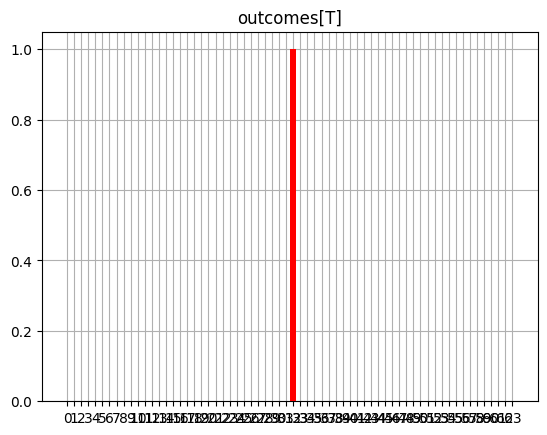

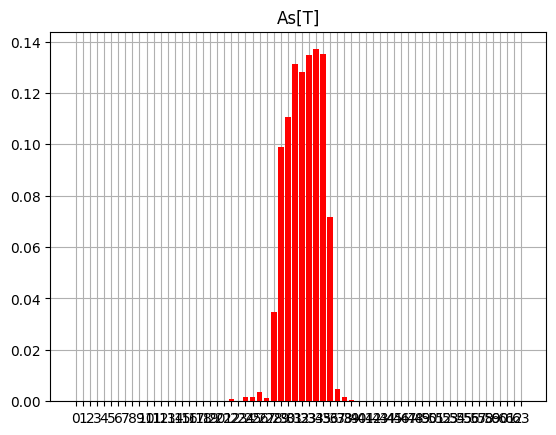

T_inference = 4
    modality = 2
    outcomes[2] = 32
    A[2]s = 31.3


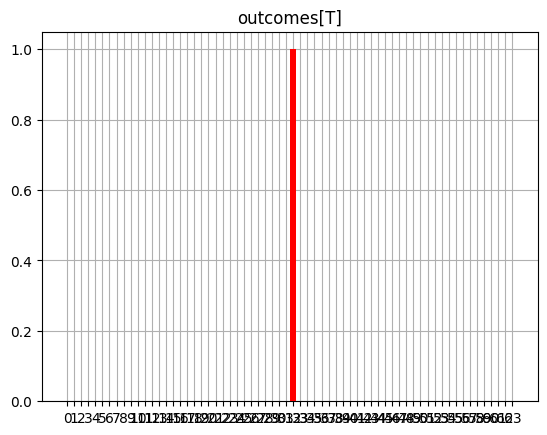

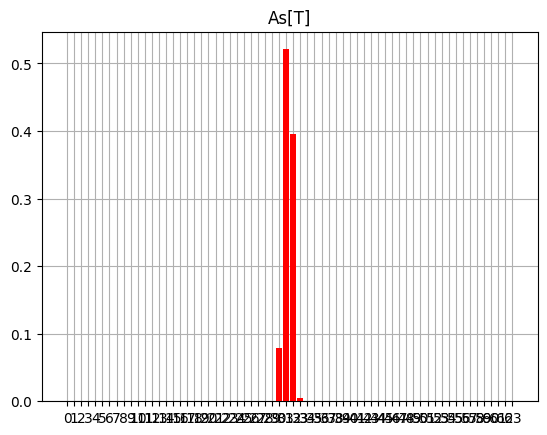

T_inference = 4
    modality = 3
    outcomes[3] = 1
    A[3]s = 0.9


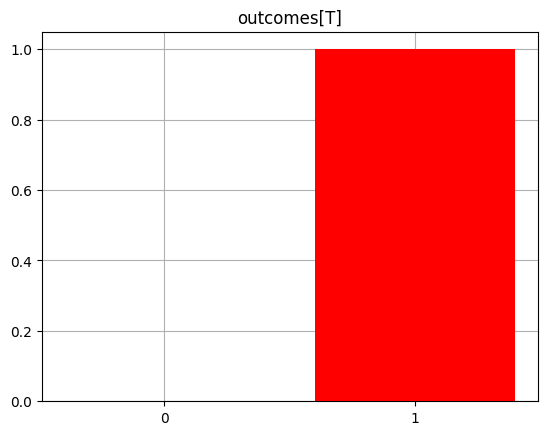

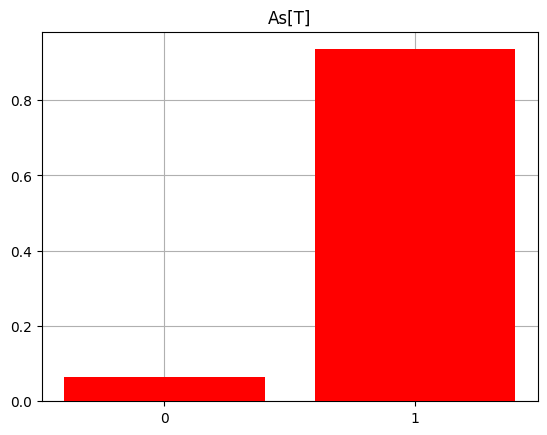

In [48]:
from pymdp.control import compute_expected_obs

for T_inference in range(T_start, T_end):

    beliefs_T_inferece = jtu.tree_map( lambda x: x[:, T_inference], infer_args[1])

    # print(f"beliefs_T_inferece shape: {[b.shape for b in beliefs_T_inferece]}")
    # print(f"agents.A shape: {[a.shape for a in agents.A]}")

    batch_num = 0
    beliefs_T_inferece_selected_batch = jtu.tree_map(lambda x: jnp.take(x, batch_num, axis=0), beliefs_T_inferece)
    A_selected_batch = jtu.tree_map(lambda x: jnp.take(x, batch_num, axis=0), agents.A)
    qo = compute_expected_obs(beliefs_T_inferece_selected_batch, A_selected_batch, agents.A_dependencies)

    for f in range(len(beliefs_T_inferece_selected_batch)):
        print(f'T_inference = {T_inference}')
        print(f'    factor = {f}')
        utils.plot_beliefs(beliefs_T_inferece_selected_batch[f], title = "qs[T]")

    for m in range(len(qo)):
        print(f'T_inference = {T_inference}')
        print(f'    modality = {m}')
        if agents.categorical_obs == False:
            print(f"    outcomes[{m}] = {outcomes[m][batch_num][T_inference]}")
            print(f"    A[{m}]s = {jnp.dot(np.arange(len(qo[m])), qo[m]):.1f}")
            utils.plot_beliefs(qo[m], title = "As[T]")
        else:
            print(f"    outcomes[{m}] = {jnp.argmax(outcomes[m][batch_num][T_inference])}") # show the index where the one-hot vector equals 1
            print(f"    A[{m}]s = {jnp.dot(np.arange(len(qo[m])), qo[m]):.1f}")
            utils.plot_beliefs(outcomes[m][batch_num][T_inference], title = "outcomes[T]")
            utils.plot_beliefs(qo[m], title = "As[T]")

T_inference = 1
    action_prev = [[0]]


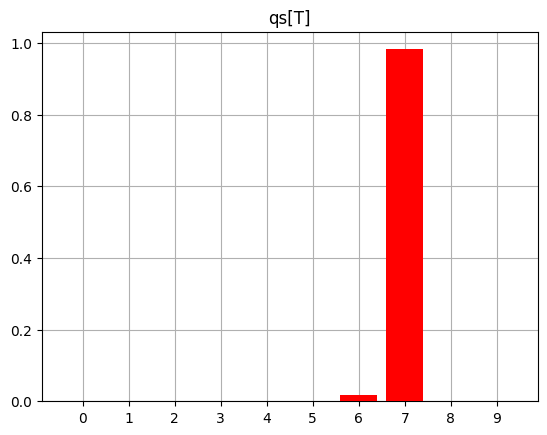

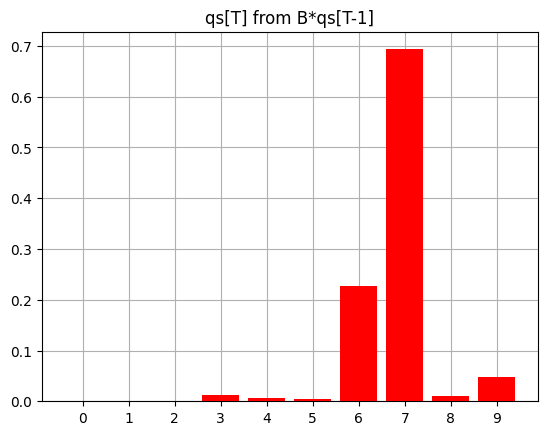

T_inference = 2
    action_prev = [[1]]


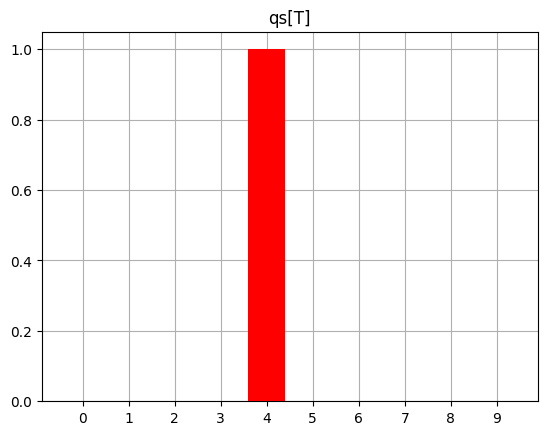

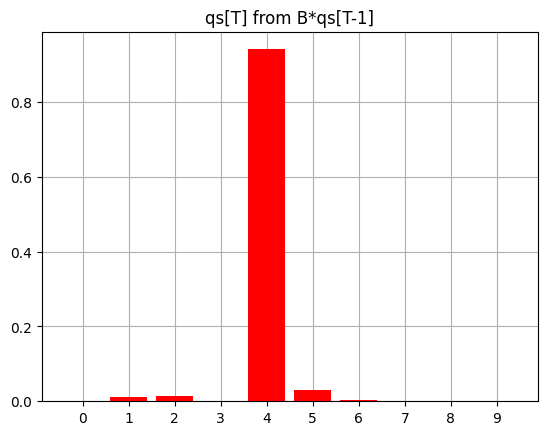

T_inference = 3
    action_prev = [[0]]


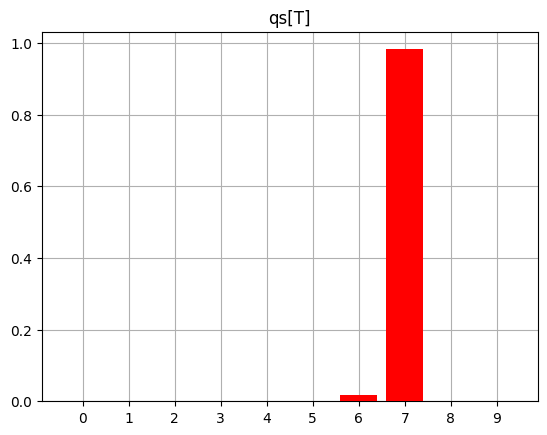

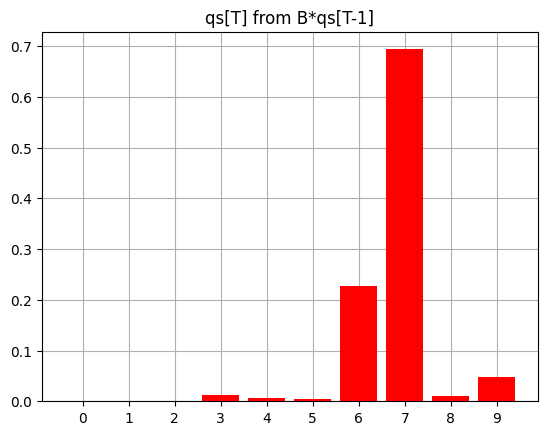

T_inference = 4
    action_prev = [[1]]


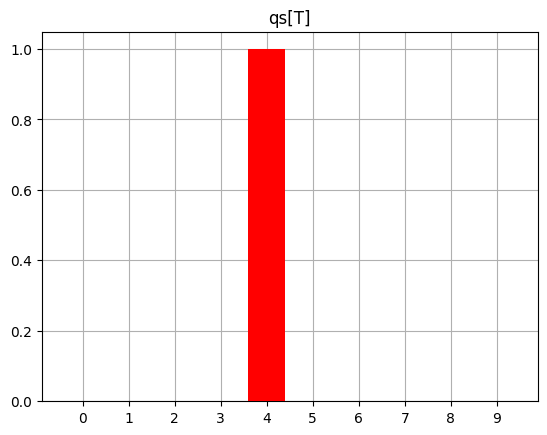

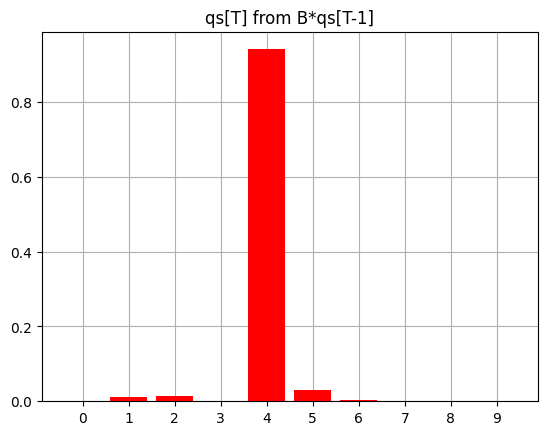

In [49]:
# Check whether the B tensor is learned correctly

from pymdp.control import compute_expected_state
from jax import vmap

for T_inference in range(T_start, T_end):

    print(f'T_inference = {T_inference}')

    batch_num = 0

    qs_0_T = infer_args[1][0][batch_num][T_inference]

    action_prev = actions[:,T_inference-1]
    print(f'    action_prev = {action_prev}')

    qs_prev = jtu.tree_map( lambda x: x[:, T_inference-1], infer_args[1])
    propagate_beliefs = partial(compute_expected_state, B_dependencies=agents.B_dependencies)
    pred = vmap(propagate_beliefs)(qs_prev, agents.B, action_prev)

    utils.plot_beliefs(qs_0_T, title = "qs[T]")
    utils.plot_beliefs(pred[0][batch_num], title = "qs[T] from B*qs[T-1]")

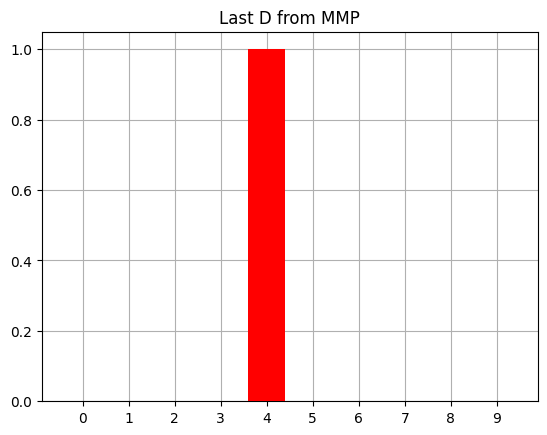

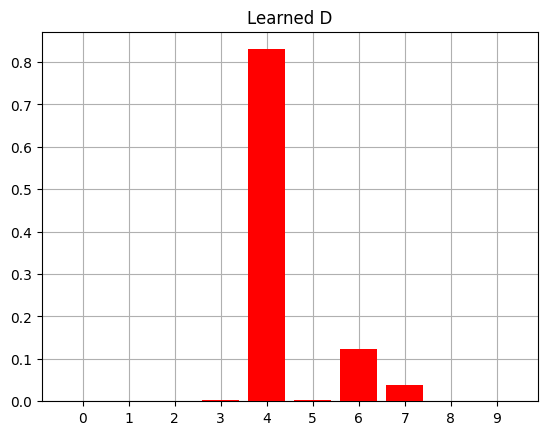

In [50]:
# Check D learning
batch_num = 0
for i in range(len(pD)):
    utils.plot_beliefs(qs_t0[i][batch_num], title = "Last D from MMP")
    utils.plot_beliefs(D_learned[i][batch_num], title = "Learned D")